# ORC1 Fiber Assay Analysis

**Purpose:** Compare replication speed and inter-origin distance between WT and MGS variants.

**Author:** Elena Lopatukhina
**Date:** 2026-07-14

## Workflow
1. Load data
2. Clean data
3. Calculate fiber speed
4. Statistical analysis
5. Plot figures
6. Save results

# 1. Libraries import

In [179]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ttest_ind

# 2. Parameters

In [180]:
INPUT_DIR = "/mnt/c/users/helen/Desktop/FIBERS"
OUTPUT_DIR = "/mnt/c/users/helen/Desktop/FIBERS"

conversion_factor = 2.59 # kb/µm
time = 20 # minutes

# 3. Data loading

In [181]:
dfs = []
all_dirs = []

for root, dirs, files in os.walk(INPUT_DIR):
    all_dirs.append(dirs)
    
    for filename in files:
        if filename.lower().endswith(".csv"):

            path = os.path.join(root, filename)
            df = pd.read_csv(path)
            
            # If everything ended up in one column, try semicolon
            if df.shape[1] == 1:
                df = pd.read_csv(path, sep=";")

            # Optional metadata
            df["File"] = os.path.splitext(filename)[0].replace(" ", "_")
            df["Path"] = path

            dfs.append(df) 

# Combine all tables
data = pd.concat(dfs, ignore_index=True)

# Create ROI column
data['ROI'] = data['Label'].apply(lambda x: x.split(":")[1])

# Create Sample name column empty (custom parsing of filenames)
data['Sample_name'] = None

# Delete first 3 columns
data.drop(data.columns[[0, 1, 2]], axis=1, inplace=True)

# Reorder columns
data = data[
    [
        "Sample_name",
        "File",
        "Measurement_type",
        "Length",
        "ROI",
        "Path"
    ]
]

print(f"Total number of files for analysis is: {data.shape[0]}")

Total number of files for analysis is: 1229


In [ ]:
# Create Sample name column empty (custom parsing of filenames)
data['Sample_name'] = data['File'].apply(lambda x: x.split("_")[1].split("-")[0])

data["Sample_name"] = data["Sample_name"].apply(
    lambda x: "WT" if "1h15min" in x else x
)

data["Sample_name"] = data["Sample_name"].apply(
    lambda x: "WT" if "30min" in x else x
)

mask = (
    (data["Sample_name"] == "HaloEmpty") &
    (data["File"].str.contains("siORC1_HaloEmpty", na=False))
)
data.loc[mask, "Sample_name"] = "siORC1"

# Update only rows where Sample_name == "HaloEmpty" and File contains "siSCR_HaloEmpty"
mask = (
    (data["Sample_name"] == "HaloEmpty") &
    (data["File"].str.contains("siSCR_HaloEmpty", na=False))
)

data.loc[mask, "Sample_name"] = "siSCR"

# Info about samples
sample_names = set(data["Sample_name"])
print(f"The amount of samples is: {len(sample_names)}.")
print(f"There are: {sample_names}")

The amount of samples is: 9.
There are: {'MGS5', 'MGS3', '30min', 'MGS2', 'WT', 'MGS1', 'siORC1', 'siSCR', 'MGS4'}


In [206]:
data[data['Sample_name']=='30min']

,Sample_name,File,Measurement_type,Length,ROI,Path
1181,30min,HCl_30min_15o_Fiber_length,Fiber_length,38.601,0424-0805,/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
1182,30min,HCl_30min_15o_Fiber_length,Fiber_length,35.735,0440-0758,/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
1183,30min,HCl_30min_15o_Fiber_length,Fiber_length,39.850,0634-0354,/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
1184,30min,HCl_30min_15o_Fiber_length,Fiber_length,32.144,0621-0313,/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
1185,30min,HCl_30min_15o_Fiber_length,Fiber_length,45.880,0426-0803,/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
1186,30min,HCl_30min_15o_Fiber_length,Fiber_length,37.805,0439-0760,/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
1187,30min,HCl_30min_15o_Fiber_length,Fiber_length,34.821,0208-1130,/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
1188,30min,HCl_30min_15o_Fiber_length,Fiber_length,30.104,0249-1121,/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
1189,30min,HCl_30min_15o_Fiber_length,Fiber_length,43.498,0633-0102,/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
1190,30min,HCl_30min_15o_Fiber_length,Fiber_length,17.717,0641-0140,/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...


In [183]:
# Split data into 2 dataframes
speed = data[data['Measurement_type']=='Fiber_length']
iod = data[data['Measurement_type']=='Interorigin_distance']

## Check data. Check the number of measurements

In [184]:
speed.head()

,Sample_name,File,Measurement_type,Length,ROI,Path
0,MGS1,siORC1_MGS1-02_Fiber_length,Fiber_length,39.080,0184-0277,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
1,MGS1,siORC1_MGS1-02_Fiber_length,Fiber_length,62.853,0207-0330,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
3,MGS1,siORC1_MGS1-03_Fiber_length,Fiber_length,55.027,0944-0253,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
4,MGS1,siORC1_MGS1-03_Fiber_length,Fiber_length,68.244,0968-0321,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
5,MGS1,siORC1_MGS1-03_Fiber_length,Fiber_length,100.000,0581-0161,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...


In [185]:
iod.head()

,Sample_name,File,Measurement_type,Length,ROI,Path
2,MGS1,siORC1_MGS1-02_Interorigin_distance,Interorigin_distance,97.944,0252-0320,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
19,MGS1,siORC1_MGS1-04_Interorigin_distance,Interorigin_distance,125.399,0550-0404,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
20,MGS1,siORC1_MGS1-04_Interorigin_distance,Interorigin_distance,171.724,0477-0521,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
21,MGS1,siORC1_MGS1-04_Interorigin_distance,Interorigin_distance,97.546,0646-0786,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
26,MGS1,siORC1_MGS1-06_Interorigin_distance,Interorigin_distance,168.964,0345-0901,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...


## Check the number of measurements

### Replication speed

In [186]:
speed.groupby('Sample_name')['File'].count()

Sample_name
30min      48
MGS1       76
MGS2      120
MGS3      128
MGS4      110
MGS5      104
WT        104
siORC1    112
siSCR     118
Name: File, dtype: int64

In [187]:
# OPTIONAL
# Check analized files
sample_name = "WT"
speed[speed["Sample_name"] == sample_name]['File'].value_counts()

File
siORC1_WT_Fiber_length                10
siORC1_WT-02_Fiber_length             10
HCl_1h15min_15o_2_-03_Fiber_length    10
HCl_1h15min_15o_Fiber_length           8
siORC1_WT-03_Fiber_length              6
siORC1_WT-05_Fiber_length              6
HCl_1h15min_15o-06_Fiber_length        6
HCl_1h15min_15o-09_Fiber_length        6
HCl_1h15min_15o-13_Fiber_length        6
HCl_1h15min_15o_2__Fiber_length        6
siORC1_WT-11_Fiber_length              4
siORC1_WT-12_Fiber_length              4
HCl_1h15min_15o-07_Fiber_length        4
HCl_1h15min_15o-14_Fiber_length        4
HCl_1h15min_15o_2_-06_Fiber_length     4
siORC1_WT-08_Fiber_length              2
siORC1_WT-14_Fiber_length              2
HCl_1h15min_15o-02_Fiber_length        2
HCl_1h15min_15o-10_Fiber_length        2
HCl_1h15min_15o_2_-05_Fiber_length     2
Name: count, dtype: int64

### IOD

In [188]:
iod.groupby('Sample_name')['File'].count()

Sample_name
MGS1      28
MGS2      48
MGS3      48
MGS4      23
MGS5      32
WT        50
siORC1    25
siSCR     55
Name: File, dtype: int64

In [189]:
# OPTIONAL
# Check analized files
#sample_name = "siORC1"
#iod[iod["Sample_name"] == sample_name]['File'].value_counts()

# 3. Process replication speed data

In [190]:
# Checking speed file
counts = speed.groupby("File").size()
odd_files = counts[counts % 2 != 0].index.tolist()

if len(odd_files) == 0:
    print("All files contain an even number of fibers.")
else:
    print("The following files contain an odd number of fibers will be removed:")
    print(*odd_files, sep="\n")
    
    # Removing odd files from speed dataframe
    speed = speed[~speed["File"].isin(odd_files)].copy()

All files contain an even number of fibers.


In [191]:
# Add extra inedex to group pairs of files
speed["Index"] = speed.groupby("File").cumcount() // 2

# Calculate sum of fiber length in pairs
speed_processed = speed.groupby(["File", "Index"], as_index=False).agg(
        Total_Length=("Length", "sum"),
        ROI=("ROI", list),
        Path=("Path", "first"),
        Sample_name=("Sample_name", "first")
        )

# Convert speed to kb/min
speed_processed['Speed_kb_min'] = speed_processed['Total_Length'].apply(lambda x: x * conversion_factor / time)

# Delete extra columns
replication_speed = speed_processed[['Sample_name', 'File', 'Speed_kb_min', 'ROI', 'Path']]

In [192]:
replication_speed

,Sample_name,File,Speed_kb_min,ROI,Path
0,WT,HCl_1h15min_15o-02_Fiber_length,7.268058,"[0172-0998, 0159-1032]",/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
1,WT,HCl_1h15min_15o-06_Fiber_length,12.962302,"[0660-0135, 0624-0181]",/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
2,WT,HCl_1h15min_15o-06_Fiber_length,9.868806,"[0627-0140, 0600-0174]",/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
3,WT,HCl_1h15min_15o-06_Fiber_length,12.087918,"[0513-0309, 0472-0351]",/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
4,WT,HCl_1h15min_15o-07_Fiber_length,8.567072,"[0490-0561, 0450-0575]",/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
...,...,...,...,...,...
455,siSCR,siSCR_HaloEmpty-27_Fiber_length,12.910762,"[0509-0834, 0529-0891]",/mnt/c/users/helen/Desktop/FIBERS/250626/siSCR...
456,siSCR,siSCR_HaloEmpty-27_Fiber_length,14.660695,"[0500-1221, 0490-1159]",/mnt/c/users/helen/Desktop/FIBERS/250626/siSCR...
457,siSCR,siSCR_HaloEmpty-27_Fiber_length,7.513978,"[0605-1169, 0615-1202]",/mnt/c/users/helen/Desktop/FIBERS/250626/siSCR...
458,siSCR,siSCR_HaloEmpty-27_Fiber_length,13.485482,"[0616-0565, 0633-0620]",/mnt/c/users/helen/Desktop/FIBERS/250626/siSCR...


# 4. Process IOD data

In [193]:
iod['IOD_kb'] = iod['Length'].apply(lambda x: x * conversion_factor)
iod_kb = iod[["Sample_name", "File", 'IOD_kb', 'ROI', 'Path']]

iod_kb.head()

,Sample_name,File,IOD_kb,ROI,Path
2,MGS1,siORC1_MGS1-02_Interorigin_distance,253.67496,0252-0320,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
19,MGS1,siORC1_MGS1-04_Interorigin_distance,324.78341,0550-0404,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
20,MGS1,siORC1_MGS1-04_Interorigin_distance,444.76516,0477-0521,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
21,MGS1,siORC1_MGS1-04_Interorigin_distance,252.64414,0646-0786,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
26,MGS1,siORC1_MGS1-06_Interorigin_distance,437.61676,0345-0901,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...


# 5. Basic statistics

## 5.1 Replication speed

In [194]:
stats_speed = (
    replication_speed.groupby("Sample_name")["Speed_kb_min"]
    .agg(
        Count="count",
        Mean="mean",
        SD="std",
    )
)

stats_speed

,Count,Mean,SD
Sample_name,,,
30min,24,10.547629,2.858905
MGS1,38,14.331530,4.351872
MGS2,60,13.001541,3.473763
MGS3,64,13.924694,3.671007
MGS4,55,14.782192,4.240110
MGS5,52,14.405338,4.566179
WT,52,13.159200,4.487109
siORC1,56,13.100377,3.594779
siSCR,59,11.347631,3.265924


## 5.2 IOD

In [195]:
stats_iod = (
    iod_kb.groupby("Sample_name")["IOD_kb"]
    .agg(
        Count="count",
        Mean="mean",
        SD="std",
    )
)

stats_iod

,Count,Mean,SD
Sample_name,,,
MGS1,28,416.126697,100.122842
MGS2,48,379.444605,118.638065
MGS3,48,433.288384,128.943988
MGS4,23,414.329394,120.159999
MGS5,32,415.471774,142.793387
WT,50,342.657570,137.682836
siORC1,25,504.970332,204.213773
siSCR,55,323.844935,107.834065


# 6. Processing outliers in data

## 6.1 Replication speed

In [196]:
Q1 = replication_speed['Speed_kb_min'].quantile(0.25)
Q3 = replication_speed['Speed_kb_min'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_speed = replication_speed[(replication_speed['Speed_kb_min'] < lower) | (replication_speed['Speed_kb_min'] > upper)]

outliers_speed

,Sample_name,File,Speed_kb_min,ROI,Path
13,WT,HCl_1h15min_15o-14_Fiber_length,30.006574,"[0372-0468, 0259-0529]",/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
14,WT,HCl_1h15min_15o-14_Fiber_length,23.987673,"[0634-0873, 0541-0914]",/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
112,MGS1,siORC1_MGS1-03_Fiber_length,24.318417,"[0581-0161, 0525-0083]",/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
133,MGS1,siORC1_MGS1-16_Fiber_length,23.946881,"[0515-0267, 0467-0357]",/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
265,MGS3,siORC1_MGS3-34_Fiber_length,24.378116,"[0700-0585, 0721-0484]",/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
272,MGS4,siORC1_MGS4-04_Fiber_length,24.698369,"[0384-0974, 0367-1077]",/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
291,MGS4,siORC1_MGS4-13_Fiber_length,24.347295,"[0441-0324, 0444-0227]",/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
321,MGS4,siORC1_MGS4-22_Fiber_length,27.060449,"[0444-0628, 0454-0742]",/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
334,MGS5,siORC1_MGS5-05_Fiber_length,23.887441,"[0361-0907, 0417-0818]",/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
358,MGS5,siORC1_MGS5-24_Fiber_length,25.081689,"[0335-0918, 0390-0835]",/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...


## 6.2 IOD

In [197]:
Q1 = iod_kb['IOD_kb'].quantile(0.25)
Q3 = iod_kb['IOD_kb'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iod = iod_kb[(iod_kb['IOD_kb'] < lower) | (iod_kb['IOD_kb'] > upper)]

outliers_iod

,Sample_name,File,IOD_kb,ROI,Path
788,siORC1,siORC1_HaloEmpty-03_Interorigin_distance,906.25654,0414-0814,/mnt/c/users/helen/Desktop/FIBERS/250626/siORC...
863,siORC1,siORC1_HaloEmpty-15_Interorigin_distance,783.43097,0612-0873,/mnt/c/users/helen/Desktop/FIBERS/250626/siORC...
877,siORC1,siORC1_HaloEmpty-16_Interorigin_distance,1066.03623,0316-0867,/mnt/c/users/helen/Desktop/FIBERS/250626/siORC...


# Graphs

## Replication speed graph

Plot is saved in the directory: /mnt/c/users/helen/Desktop/FIBERS


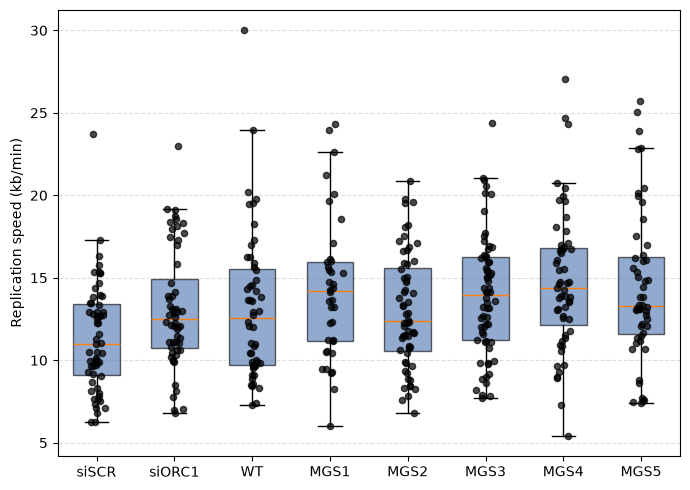

In [198]:
plt.figure(figsize=(7, 5))

# Variables
data_plot = replication_speed
var = "Speed_kb_min"

# Order of groups (optional)
sample_order = ["siSCR", "siORC1", "WT", "MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]

groups = []
labels = []

for sample in sample_order:
        values = data_plot.loc[
        data_plot["Sample_name"] == sample,
        var
    ]
        
        groups.append(values)
        labels.append(sample)

    

bp = plt.boxplot(
    groups,
    patch_artist=True,
    showfliers=False,
    widths=0.6,
)

for box in bp["boxes"]:
    box.set(facecolor="#4C72B0", alpha=0.6)

# Jittered dots
for i, values in enumerate(groups, start=1):
    x = np.random.normal(i, 0.05, len(values))
    plt.scatter(x, values, s=20, color="black", alpha=0.7, zorder=3)

plt.ylabel("Replication speed (kb/min)")
plt.xticks(range(1, len(labels) + 1), labels)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/replication_speed_boxplot.png", dpi=600, bbox_inches="tight")
print(f"Plot is saved in the directory: {OUTPUT_DIR}")

plt.show()

## IOD graph

Plot is saved in the directory: /mnt/c/users/helen/Desktop/FIBERS


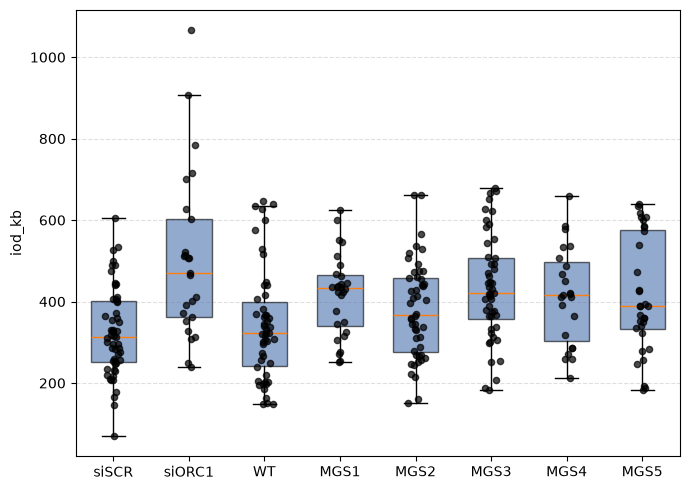

In [199]:
plt.figure(figsize=(7, 5))

# Variables
data_plot = iod_kb
var = "IOD_kb"

# Order of groups (optional)
sample_order = ["siSCR", "siORC1", "WT", "MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]

groups = []
labels = []

for sample in sample_order:
        values = data_plot.loc[
        data_plot["Sample_name"] == sample,
        var
    ]
        
        groups.append(values)
        labels.append(sample)

    

bp = plt.boxplot(
    groups,
    patch_artist=True,
    showfliers=False,
    widths=0.6,
)

for box in bp["boxes"]:
    box.set(facecolor="#4C72B0", alpha=0.6)

# Jittered dots
for i, values in enumerate(groups, start=1):
    x = np.random.normal(i, 0.05, len(values))
    plt.scatter(x, values, s=20, color="black", alpha=0.7, zorder=3)

plt.ylabel("iod_kb")
plt.xticks(range(1, len(labels) + 1), labels)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/iod_boxplot.png", dpi=600, bbox_inches="tight")
print(f"Plot is saved in the directory: {OUTPUT_DIR}")

plt.show()

# Statistical analysis

## U-test

### Replication speed

In [200]:
# Data
data_plot = replication_speed
var = "Speed_kb_min"

wt = data_plot.loc[
    data_plot["Sample_name"] == "WT",
    var
].dropna()

results = []

for sample in ["siSCR", "siORC1", "MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]:

    mutant = data_plot.loc[
        data_plot["Sample_name"] == sample,
        var
    ].dropna()

    stat, p = mannwhitneyu(
        wt,
        mutant
    )

    results.append({
        "Comparison": f"WT vs {sample}",
        "WT_n": len(wt),
        "Sample_n": len(mutant),
        "U": stat,
        "p-value": p,
    })

stats_u_df = pd.DataFrame(results)

print(stats_u_df)

     Comparison  WT_n  Sample_n       U   p-value
0   WT vs siSCR    52        59  1884.0  0.038887
1  WT vs siORC1    52        56  1377.0  0.629329
2    WT vs MGS1    52        38   798.0  0.121610
3    WT vs MGS2    52        60  1512.0  0.781688
4    WT vs MGS3    52        64  1387.0  0.124790
5    WT vs MGS4    52        55  1049.0  0.017709
6    WT vs MGS5    52        52  1103.0  0.106193


### IOD

In [201]:
# Data
data_plot = iod_kb
var = "IOD_kb"

wt = data_plot.loc[
    data_plot["Sample_name"] == "WT",
    var
].dropna()

results = []

for sample in ["siSCR", "siORC1", "MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]:

    mutant = data_plot.loc[
        data_plot["Sample_name"] == sample,
        var
    ].dropna()

    stat, p = mannwhitneyu(
        wt,
        mutant
    )

    results.append({
        "Comparison": f"WT vs {sample}",
        "WT_n": len(wt),
        "Sample_n": len(mutant),
        "U": stat,
        "p-value": p,
    })

stats_u_df = pd.DataFrame(results)

print(stats_u_df)

     Comparison  WT_n  Sample_n       U   p-value
0   WT vs siSCR    50        55  1439.0  0.683698
1  WT vs siORC1    50        25   306.0  0.000344
2    WT vs MGS1    50        28   434.0  0.005683
3    WT vs MGS2    50        48   945.0  0.070505
4    WT vs MGS3    50        48   711.0  0.000517
5    WT vs MGS4    50        23   377.0  0.019013
6    WT vs MGS5    50        32   562.0  0.023968


## T-Test

In [202]:
# Data
data_plot = iod_kb
var = "IOD_kb"

wt = data_plot.loc[
    data_plot["Sample_name"] == "WT",
    var
].dropna()

results = []

for sample in ["siSCR", "siORC1", "MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]:

    mutant = data_plot.loc[
        data_plot["Sample_name"] == sample,
        var
    ].dropna()

    stat, p = ttest_ind(
        wt,
        mutant,
        equal_var=False,   # Welch's t-test (recommended)
    )

    results.append({
        "Comparison": f"WT vs {sample}",
        "WT_n": len(wt),
        "Sample_n": len(mutant),
        "U": stat,
        "p-value": p,
    })

stats_t_df = pd.DataFrame(results)

print(stats_t_df)

     Comparison  WT_n  Sample_n         U   p-value
0   WT vs siSCR    50        55  0.774141  0.440817
1  WT vs siORC1    50        25 -3.587286  0.001004
2    WT vs MGS1    50        28 -2.705991  0.008528
3    WT vs MGS2    50        48 -1.418710  0.159259
4    WT vs MGS3    50        48 -3.364743  0.001103
5    WT vs MGS4    50        23 -2.258695  0.028422
6    WT vs MGS5    50        32 -2.284028  0.025674


# Statistical tables export

In [203]:

replication_speed.to_excel(f"{input_dir}/replication_speed.xlsx", index=False)
iod_kb.to_excel(f"{input_dir}/iod_kb.xlsx", index=False)

NameError: name 'input_dir' is not defined